Adapted from https://github.com/marcdelabarrera/nndp/tree/main/docs/source/notebooks/income_fluctuations

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from deep_macrofin import PDEModel
from deep_macrofin import Comparator, OptimizerType, LossReductionMethod, set_seeds
from tqdm import tqdm
from torch.func import jacrev, hessian, vmap

In [ ]:
class PDEModelCustomSample(PDEModel):
    def __init__(self, name, config, latex_var_mapping={}):
        super().__init__(name, config, latex_var_mapping)
        self.sample = self.sample_custom

    def sample_custom(self, epoch):
        N = self.batch_size
        t = torch.zeros(N, device=self.device)
        y = torch.exp(torch.tensor(
            np.random.uniform(
                self.state_variable_constraints["sv_low"][1],
                self.state_variable_constraints["sv_high"][1],
                N
            ), dtype=torch.float32, device=self.device))
        a = torch.tensor(
            np.random.uniform(
                self.state_variable_constraints["sv_low"][2],
                self.state_variable_constraints["sv_high"][2],
                N
        ), dtype=torch.float32, device=self.device)
        return torch.stack([t, y, a], dim=1)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "./models/income_fluctuation"
params = {
    "T": 10, # number of periods, t=0,...,T, where death occurs at T
    "beta": 0.98, # discount factor
    "gamma": 1.1, # relative risk aversion,
    "rho": 0.9, # persistance of AR(1)
    "sigma_y": 0.2, # transitory shock variable
    "N_simul": 20,
}
params["R"] = 1/params["beta"] # interest rate
params["sigma_y_st"] = params["sigma_y"] / torch.sqrt(1. - torch.tensor(params["rho"]) ** 2)
logy_bound = [-2 * params["sigma_y_st"], 2 * params["sigma_y_st"]]
a_bound = [0, 10]

In [ ]:
def compute_u(t, c, T, beta, gamma):
    crra = (beta**t)*(c**(1-gamma))/(1-gamma)
    return torch.where(t<=T, crra, 0)

def compute_value_function(SV: torch.Tensor, compute_pi, compute_u, T, beta, gamma, rho, sigma_y, R, N_simul):
    B = SV.shape[0]
    SV = torch.repeat_interleave(SV, repeats=N_simul, dim=0) # For each initial value, perform N_simul monte carlo samples
    V = torch.zeros((SV.shape[0], 1), device=SV.device) # (B*N_simul, 1)
    curr_state = SV
    for time_iter in range(T + 1):
        t = curr_state[...,0:1] # (B*N_simul, 1)
        y = curr_state[...,1:2] # (B*N_simul, 1)
        a = curr_state[...,2:3] # (B*N_simul, 1)

        # compute policy and value function
        action = compute_pi(curr_state) * (y + a) # (B*N_simul, 1)
        V += compute_u(curr_state[..., 0:1], action, T, beta, gamma)

        # update to next state
        t_next = t + 1 # (B*N_simul, 1)
        eps = torch.randn_like(y)
        y_next = torch.exp(rho * torch.log(y) + sigma_y * eps) # (B*N_simul, 1)
        a_next = R * (a + y - action) # (B*N_simul, 1)
        curr_state = torch.cat([t_next, y_next, a_next], dim=1)
    V = V.reshape(B, N_simul, 1).mean(dim=1) # average across all monte carlo samples to find the expectation
    return -torch.mean(V) # the final loss is the average across all batches, we want to maximize the value function, so negative loss

def get_model(model_path: str, params: dict, model_size: list[int]):
    set_seeds(0)
    model = PDEModelCustomSample("income_fluctuation", config={"batch_size": 100, "num_epochs": 100, "optimizer_type": OptimizerType.Adam, "lr": 1e-3, "loss_log_interval": 1})
    model.set_state(["t", "y", "a"], 
        {"t": [0, params["T"] + 1], "y": logy_bound, "a": a_bound} # override sampling
    )
    model.add_agent("pi", config={"hidden_units": model_size, "derivative_order": 0, "sigmoid": True})
    model.add_params(params)
    model.register_functions([
        compute_u, compute_value_function
    ])
    model.add_equations([
        "V=compute_value_function(SV, compute_pi, compute_u, T, beta, gamma, rho, sigma_y, R, N_simul)"
    ])
    model.add_hjb_equation("V", loss_reduction=LossReductionMethod.NONE)
    if not os.path.exists(f"{model_path}/model.pt"):
        model.train_model(model_path, "model.pt", True)
    model.load_model(torch.load(f"{model_path}/model_best.pt", weights_only=False))
    return model

In [5]:
model = get_model(model_path, params, [128]*5)

Model loaded


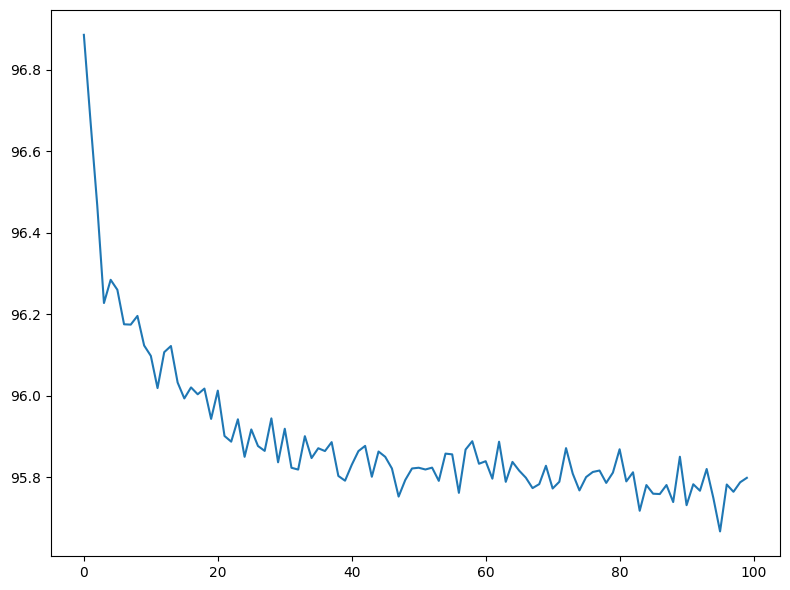

In [6]:
loss_dict = pd.read_csv(f"{model_path}/model_loss.csv")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(loss_dict["epoch"], loss_dict["total_loss"])
plt.tight_layout()
plt.show()

0 0.6799261 0.5529377 0.80067873
2 0.6481426 0.5307434 0.7757789
4 0.7112817 0.5916927 0.8259524
6 0.82315797 0.7244332 0.8979463
8 0.89726454 0.83946264 0.93513304
10 0.932087 0.90193945 0.9512047


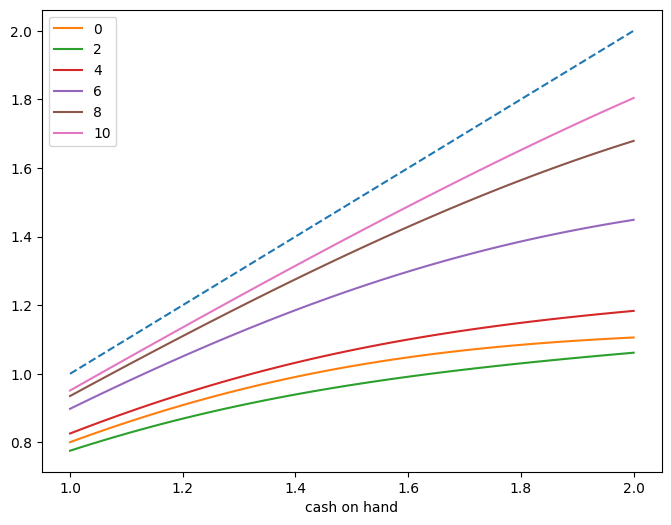

In [7]:
a = torch.linspace(0, 1, 50, device=model.device)
y_plot = 1
baseline_x = a.detach().cpu().numpy() + y_plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(baseline_x, baseline_x, ls="--")
for t in range(0, params["T"]+1, 2):
    s = torch.stack([
        torch.ones_like(a, device=model.device) * t,
        torch.ones_like(a, device=model.device) * y_plot,
        a,
    ], dim=1)
    share = model.agents["pi"](s).detach().cpu().numpy()
    print(t, share.mean(), share.min(), share.max())
    fitted_value = model.agents["pi"](s).detach().cpu().numpy().reshape(-1) * baseline_x
    ax.plot(baseline_x, fitted_value, label=t)
ax.legend()
ax.set_xlabel("cash on hand")
plt.show()